# 1. LIBRERIAS Y FUNCIONES

In [8]:
# Cargamos Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# modelos lineales
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

# indicadores de ajuste del modelo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,mean_squared_error,r2_score,confusion_matrix,recall_score,classification_report,precision_score,f1_score
from sklearn.metrics import roc_curve, roc_auc_score

# modelos de árboles de decisión
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import GridSearchCV

# ÁRBOLES DE DECISIÓN - REGRESIÓN

## 🌳 Concepto básico
- **Definición:** Un árbol de decisión de regresión divide el espacio de datos en regiones homogéneas y asigna un valor promedio en cada hoja.  
- **Objetivo:** Predecir una variable continua (ejemplo: costos hospitalarios, ingresos, tiempo de espera).  
- **Construcción:** Se basa en el algoritmo CART, que selecciona divisiones en las variables para minimizar el error cuadrático medio (MSE).

---

## 📊 Interpretación
- Cada **nodo interno** representa una condición sobre una variable (ej. “edad < 40”).  
- Cada **hoja** contiene un valor numérico (ej. costo promedio de pacientes en ese grupo).  
- La interpretación es directa: se puede seguir el camino del árbol para explicar la predicción.

---

## 📏 Medidas de ajuste
- **MSE (Mean Squared Error):** mide el promedio de los errores al cuadrado.  
- **MAE (Mean Absolute Error):** mide el promedio de los errores absolutos.  
- **R² (Coeficiente de determinación):** indica qué proporción de la variabilidad de la variable dependiente explica el modelo.  

---

## ✅ Ventajas
- Fácil de **visualizar y explicar** en clase.  
- No requiere supuestos de linealidad.  
- Puede manejar relaciones no lineales y variables categóricas.  
- Útil para **interpretación pedagógica** y escenarios prácticos como hospital accounting o business analytics.

## ⚠️ Desventajas
- Riesgo de **sobreajuste** si el árbol es muy profundo.  
- Menor capacidad de generalización comparado con modelos más robustos (ej. Random Forest, Gradient Boosting).  
- Sensibles a pequeñas variaciones en los datos.


In [9]:
# cargamos datos
resultados = pd.read_csv('evaluacionh2/healthcare_dataset.csv',sep=',', encoding='iso-8859-1')

print(resultados.shape) #
resultados.head(2)

(55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive


In [10]:
resultados['Age'].describe()

count    55500.000000
mean        51.539459
std         19.602454
min         13.000000
25%         35.000000
50%         52.000000
75%         68.000000
max         89.000000
Name: Age, dtype: float64

In [11]:
resultados['Blood Type'].value_counts()

Blood Type
A-     6969
A+     6956
AB+    6947
AB-    6945
B+     6945
B-     6944
O+     6917
O-     6877
Name: count, dtype: int64

In [12]:
# una copia de la fuente de datos
df = resultados.copy()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage: 6.4 MB


In [13]:
# a dummies las variables categoricas
df = pd.get_dummies(df, columns=['Hospital','Gender','Medication'], drop_first=True)
print(df.shape)
df.head(2)

(55500, 39892)


,Name,Age,Blood Type,Medical Condition,Date of Admission,Doctor,Insurance Provider,Billing Amount,Room Number,Admission Type,...,Hospital_and Zimmerman Sons,"Hospital_and Zuniga Davis Carlson,","Hospital_and Zuniga Francis Peterson,",Hospital_and Zuniga Sons,"Hospital_and Zuniga Thompson, Blake",Gender_Male,Medication_Ibuprofen,Medication_Lipitor,Medication_Paracetamol,Medication_Penicillin
0,Bobby JacksOn,30,B-,Cancer,2024-01-31,Matthew Smith,Blue Cross,18856.281306,328,Urgent,...,False,False,False,False,False,True,False,False,True,False
1,LesLie TErRy,62,A+,Obesity,2019-08-20,Samantha Davies,Medicare,33643.327287,265,Emergency,...,False,False,False,False,False,True,True,False,False,False


In [17]:
# Definir las variables independientes y dependientes
X = df[['Age','Insurance Provider',]] # variables independientes
#X = df[['age', 'bmi', 'smoker_yes']]
y = df['Blood Type'] # variables dependiente

# Añadir una constante a las variables independientes
X = sm.add_constant(X) # relacionado intercepto
X.head(2)

,const,Age,Insurance Provider
0,1.0,30,Blue Cross
1,1.0,62,Medicare


In [24]:
# División de conjunto de datos en entrenamiento y testeo
# train - test
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 22) #Separamos 30% para test

In [29]:
x_train_procesado = pd.get_dummies(x_train_temp)

In [32]:
print(x_train.dtypes)

const                 float64
Age                     int64
Insurance Provider        str
dtype: object


In [35]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor

# 1. Procesamos X: Convertimos TODAS las columnas de texto a números
# Esto se encarga de 'A-', 'Aetna' y cualquier otro string en Insurance Provider
x_train_final = pd.get_dummies(x_train.drop(columns='const', errors='ignore'))

# 2. PROCESAMOS Y: Si y_train tiene letras (como 'A-'), el Regressor fallará.
# Lo convertimos a números también. Si es tu variable objetivo y tiene texto, 
# quizás deberías usar LabelEncoder o cerciorarte de qué datos hay ahí.
if y_train.dtype == 'object' or y_train.dtype == 'str':
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y_train = le.fit_transform(y_train)

# 3. Configurar el modelo
modelo_ArbolDecisionRegres = DecisionTreeRegressor(
    max_depth=2, 
    min_samples_leaf=1, 
    min_samples_split=2
)

# 4. Entrenar
modelo_ArbolDecisionRegres.fit(x_train_final, y_train)

print(f"Columnas procesadas en X: {list(x_train_final.columns)}")

Columnas procesadas en X: ['Age', 'Insurance Provider_Aetna', 'Insurance Provider_Blue Cross', 'Insurance Provider_Cigna', 'Insurance Provider_Medicare', 'Insurance Provider_UnitedHealthcare']


In [38]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split

# 1. Cargar el dataset
df = pd.read_csv('evaluacionh2/healthcare_dataset.csv')

# 2. Seleccionar variables (X) y el objetivo (y)
# Por ejemplo, intentaremos predecir el 'Billing Amount' (Monto de facturación)
# Usaremos Edad, Género, Tipo de Sangre y Proveedor de Seguro como predictores
columnas_x = ['Age', 'Gender', 'Blood Type', 'Medical Condition', 'Insurance Provider']
X = df[columnas_x]
y = df['Billing Amount']

# 3. CONVERSIÓN CRÍTICA: Transformar texto a números
# Esto crea columnas de 0 y 1 para 'Gender', 'Blood Type', etc.
# Esto elimina los errores de "could not convert string to float"
X_procesado = pd.get_dummies(X, drop_first=True)

# 4. Dividir en entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(X_procesado, y, test_size=0.2, random_state=42)

# 5. Configurar y entrenar el modelo (con tus parámetros)
modelo_ArbolDecisionRegres = DecisionTreeRegressor(
    max_depth=2, 
    min_samples_leaf=1, 
    min_samples_split=2
)

modelo_ArbolDecisionRegres.fit(x_train, y_train)

# 6. Verificar resultado
print("¡Entrenamiento exitoso!")
print(f"Columnas después de procesar el CSV: {list(X_procesado.columns[:5])} ... (total: {len(X_procesado.columns)})")
print(f"Score del modelo: {modelo_ArbolDecisionRegres.score(x_test, y_test)}")

¡Entrenamiento exitoso!
Columnas después de procesar el CSV: ['Age', 'Gender_Male', 'Blood Type_A-', 'Blood Type_AB+', 'Blood Type_AB-'] ... (total: 18)
Score del modelo: -0.0004118740917433694


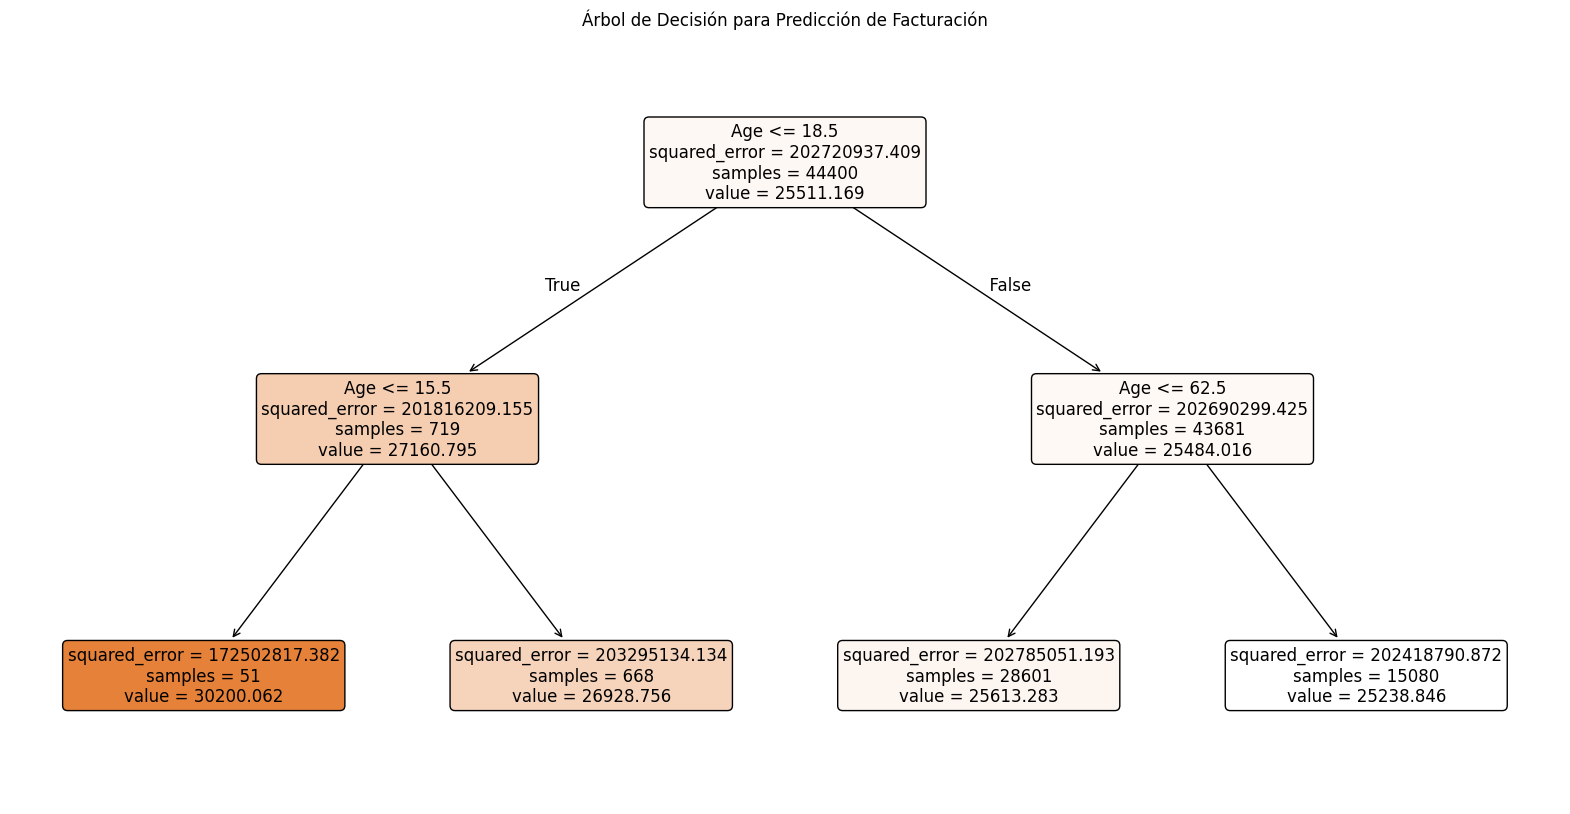

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split

# 1. Cargar y preparar datos (basado en tu CSV)
df = pd.read_csv('evaluacionh2/healthcare_dataset.csv')
columnas_x = ['Age', 'Gender', 'Blood Type', 'Insurance Provider']
X = pd.get_dummies(df[columnas_x], drop_first=True)
y = df['Billing Amount']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Entrenar el modelo
modelo_ArbolDecisionRegres = DecisionTreeRegressor(max_depth=2)
modelo_ArbolDecisionRegres.fit(x_train, y_train)

# 3. GENERAR LA GRÁFICA
plt.figure(figsize=(20, 10))  # Ajusta el tamaño de la imagen
plot_tree(
    modelo_ArbolDecisionRegres, 
    feature_names=X.columns.tolist(), 
    filled=True, 
    rounded=True, 
    fontsize=12
)
plt.title("Árbol de Decisión para Predicción de Facturación")
plt.show()

In [40]:
## Ajustar el modelo de regresión lineal
#modelo_OLS = sm.OLS(y_train, x_train).fit()
#
## Resumen del modelo
#print(modelo_OLS.summary())

In [43]:
# ajustamos el indice en la data de test
x_test.reset_index(drop=True, inplace=True)

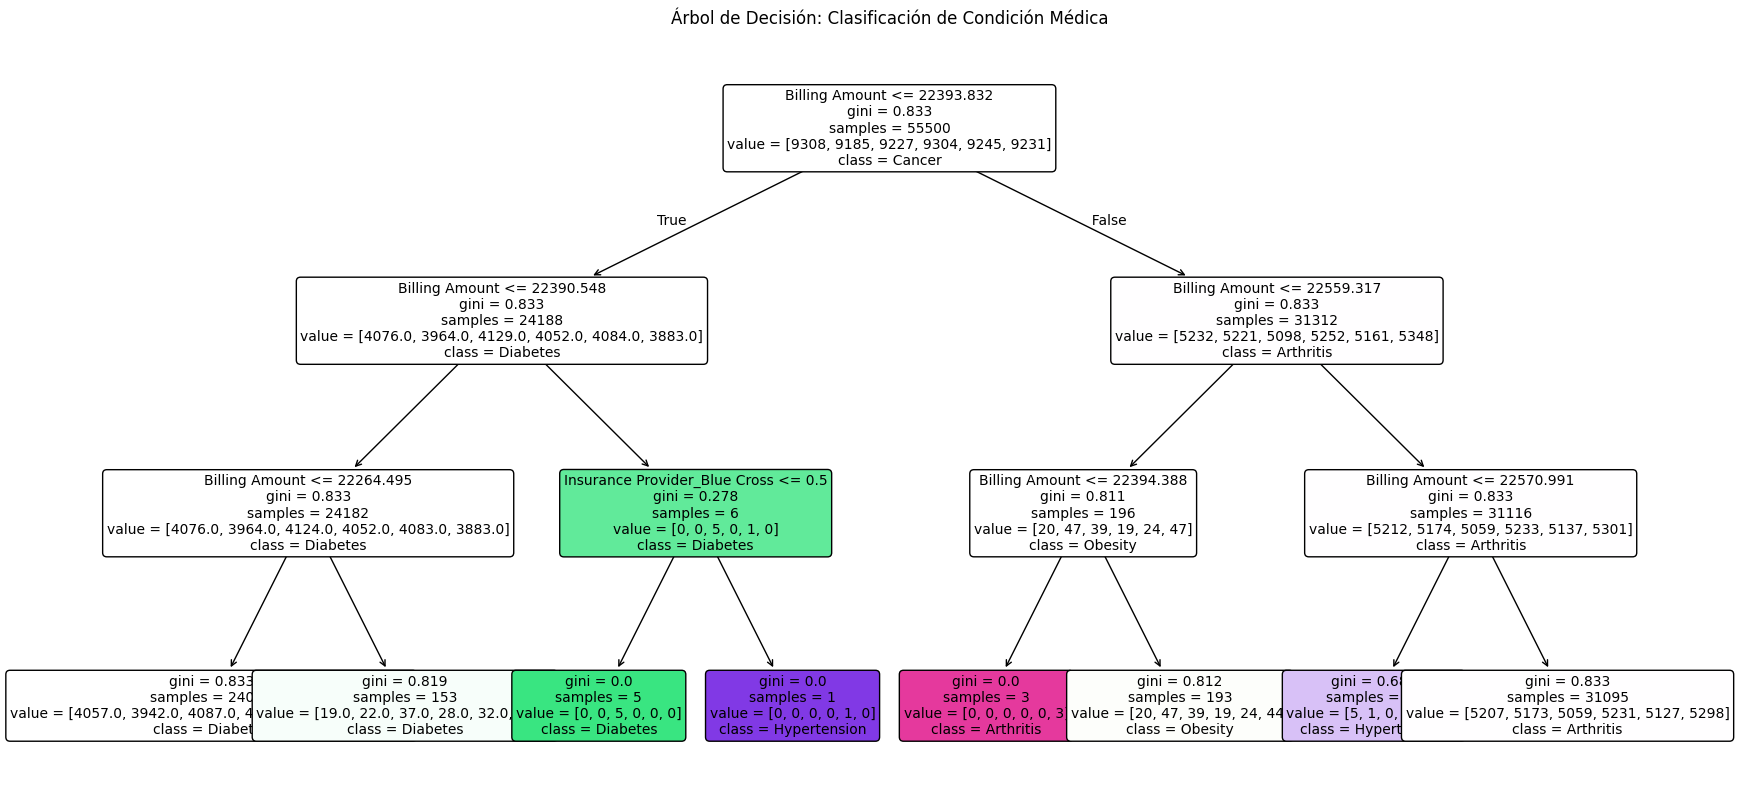

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

# 1. Cargar el dataset
df = pd.read_csv('evaluacionh2/healthcare_dataset.csv')

# 2. Configurar variables
# Para clasificación, 'y' debe ser una categoría (ejemplo: 'Medical Condition')
# 'X' serán las características numéricas y categóricas convertidas
columnas_x = ['Age', 'Billing Amount', 'Gender', 'Insurance Provider']
X = pd.get_dummies(df[columnas_x], drop_first=True)
y = df['Medical Condition'] 

# 3. Entrenar el modelo de CLASIFICACIÓN (como en tu captura)
modelo_Clasif = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo_Clasif.fit(X, y)

# 4. Generar el gráfico del árbol
plt.figure(figsize=(20, 10))
plot_tree(
    modelo_Clasif, 
    feature_names=X.columns.tolist(), 
    class_names=y.unique().tolist(), # Muestra el nombre de la enfermedad en el nodo
    filled=True, 
    rounded=True,
    fontsize=10
)

plt.title("Árbol de Decisión: Clasificación de Condición Médica")
plt.show()

--- Comparación de los primeros 10 resultados ---
      Valor Real Predicción
31641   Diabetes     Cancer
9246    Diabetes    Obesity
1583      Asthma    Obesity
36506    Obesity    Obesity
11259    Obesity    Obesity
8972      Cancer     Cancer
36078     Asthma    Obesity
42659   Diabetes    Obesity
6545   Arthritis     Cancer
35448     Cancer    Obesity


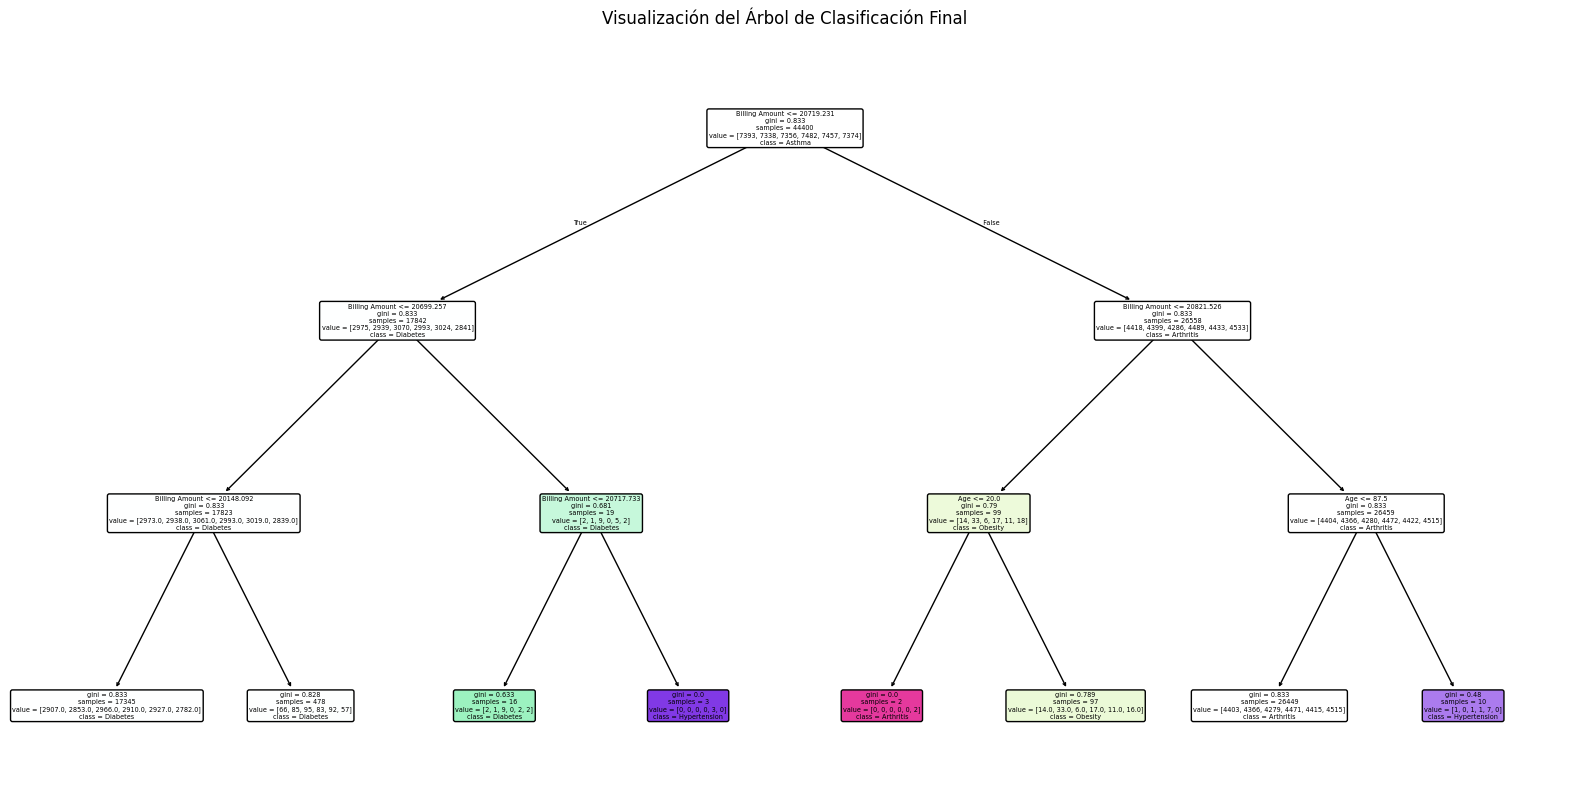

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# 1. Preparación de datos (usando tu CSV)
df = pd.read_csv('evaluacionh2/healthcare_dataset.csv')
columnas_x = ['Age', 'Billing Amount', 'Gender', 'Blood Type']
X = pd.get_dummies(df[columnas_x], drop_first=True)
y = df['Medical Condition']

# Dividimos los datos (80% entrenamiento, 20% prueba)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Entrenar el modelo de Clasificación
modelo_Clasif = DecisionTreeClassifier(max_depth=3)
modelo_Clasif.fit(x_train, y_train)

# 3. PREDICCIÓN (Lo que aparece en tu nueva captura)
y_pred = modelo_Clasif.predict(x_test)

# Creamos el DataFrame comparativo
comparacion = pd.DataFrame({'Valor Real': y_test, 'Predicción': y_pred})
print("--- Comparación de los primeros 10 resultados ---")
print(comparacion.head(10))

# 4. GRÁFICA DEL ÁRBOL (Para visualizar la lógica)
plt.figure(figsize=(20, 10))
from sklearn.tree import plot_tree
plot_tree(
    modelo_Clasif, 
    feature_names=X.columns.tolist(), 
    class_names=y.unique().tolist(), 
    filled=True, 
    rounded=True
)
plt.title("Visualización del Árbol de Clasificación Final")
plt.show()

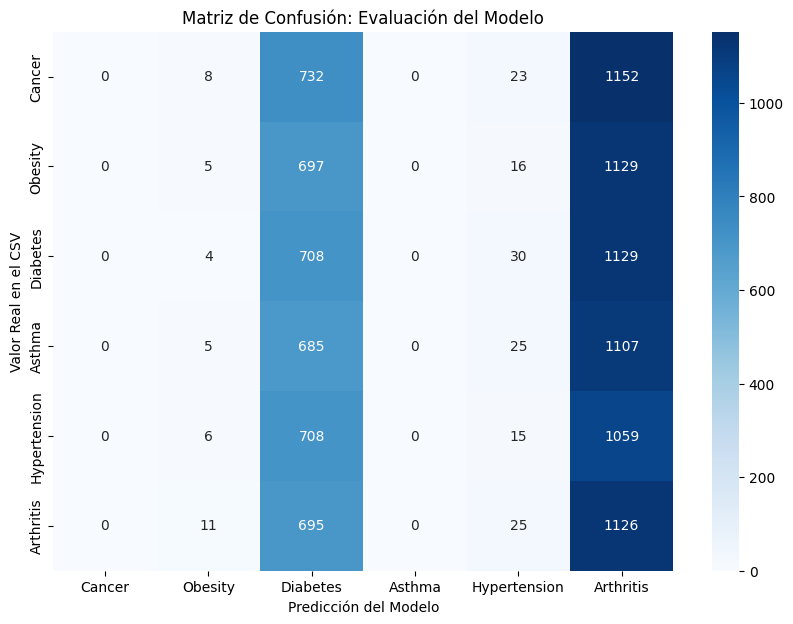

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

   Arthritis       0.00      0.00      0.00      1915
      Asthma       0.13      0.00      0.01      1847
      Cancer       0.17      0.38      0.23      1871
    Diabetes       0.00      0.00      0.00      1822
Hypertension       0.11      0.01      0.02      1788
     Obesity       0.17      0.61      0.26      1857

    accuracy                           0.17     11100
   macro avg       0.10      0.17      0.09     11100
weighted avg       0.10      0.17      0.09     11100

Precisión Total: 16.70%


c:\Users\peral\miniconda3\envs\mineria\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\peral\miniconda3\envs\mineria\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\peral\miniconda3\envs\mineria\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Preparación de datos
df = pd.read_csv('evaluacionh2/healthcare_dataset.csv')
columnas_x = ['Age', 'Billing Amount', 'Gender', 'Blood Type']
X = pd.get_dummies(df[columnas_x], drop_first=True)
y = df['Medical Condition']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Entrenar el modelo
modelo_Clasif = DecisionTreeClassifier(max_depth=4)
modelo_Clasif.fit(x_train, y_train)

# 3. Predicciones
y_pred = modelo_Clasif.predict(x_test)

# 4. MATRIZ DE CONFUSIÓN (Lo que muestra tu imagen)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=y.unique(), yticklabels=y.unique())
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real en el CSV')
plt.title('Matriz de Confusión: Evaluación del Modelo')
plt.show()

# 5. Reporte de Precisión
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))
print(f"Precisión Total: {accuracy_score(y_test, y_pred):.2%}")

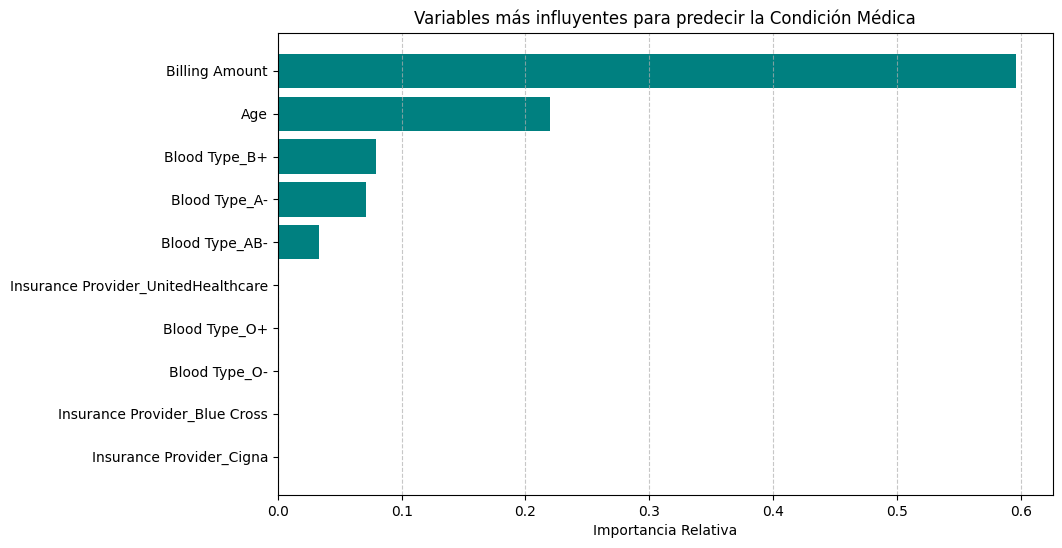

Variable: Age -> Importancia: 0.2199
Variable: Billing Amount -> Importancia: 0.5962
Variable: Blood Type_A- -> Importancia: 0.0713
Variable: Blood Type_AB- -> Importancia: 0.0336
Variable: Blood Type_B+ -> Importancia: 0.0790


In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# 1. Preparación de datos
df = pd.read_csv('evaluacionh2/healthcare_dataset.csv')
columnas_x = ['Age', 'Billing Amount', 'Gender', 'Blood Type', 'Insurance Provider']
X = pd.get_dummies(df[columnas_x], drop_first=True)
y = df['Medical Condition']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Entrenar el modelo
modelo_Clasif = DecisionTreeClassifier(max_depth=4)
modelo_Clasif.fit(x_train, y_train)

# 3. CÁLCULO DE IMPORTANCIA DE VARIABLES (Lo que muestra tu imagen)
importancias = modelo_Clasif.feature_importances_
nombres_columnas = X.columns

# Ordenar las importancias para que el gráfico se vea mejor
indices = np.argsort(importancias)[-10:]  # Tomamos las 10 más importantes

# 4. Graficar
plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importancias[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [nombres_columnas[i] for i in indices])
plt.xlabel('Importancia Relativa')
plt.title('Variables más influyentes para predecir la Condición Médica')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Mostrar en texto también
for nombre, imp in zip(nombres_columnas, importancias):
    if imp > 0:
        print(f"Variable: {nombre} -> Importancia: {imp:.4f}")

c:\Users\peral\miniconda3\envs\mineria\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


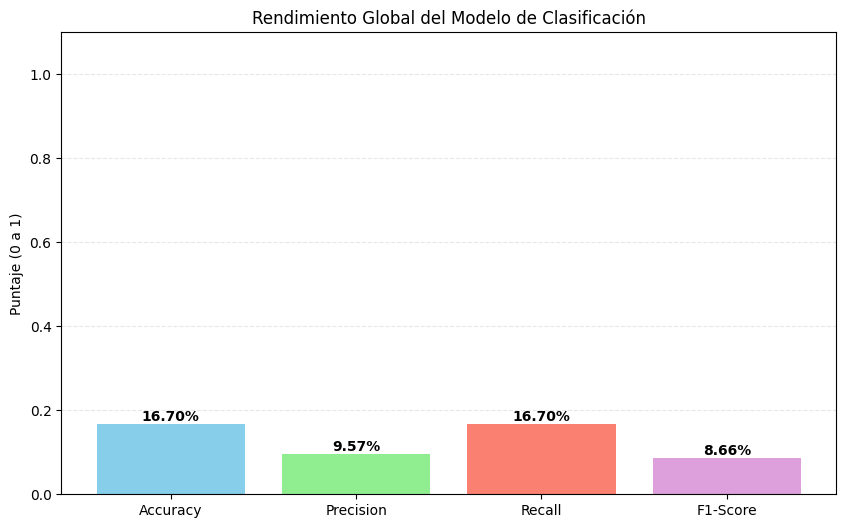

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# 1. Preparar datos y entrenar (proceso estándar)
df = pd.read_csv('evaluacionh2/healthcare_dataset.csv')
X = pd.get_dummies(df[['Age', 'Billing Amount', 'Gender', 'Blood Type']], drop_first=True)
y = df['Medical Condition']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelo = DecisionTreeClassifier(max_depth=4)
modelo.fit(x_train, y_train)
y_pred = modelo.predict(x_test)

# 2. CALCULAR MÉTRICAS (Lo que ves en tu captura)
# Usamos 'weighted' porque tienes varias enfermedades (multiclase)
metricas = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted'),
    'Recall': recall_score(y_test, y_pred, average='weighted'),
    'F1-Score': f1_score(y_test, y_pred, average='weighted')
}

# 3. GENERAR EL GRÁFICO DE BARRAS
nombres = list(metricas.keys())
valores = list(metricas.values())

plt.figure(figsize=(10, 6))
barras = plt.bar(nombres, valores, color=['skyblue', 'lightgreen', 'salmon', 'plum'])

# Añadir los porcentajes sobre las barras para que sea igual a tu imagen
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval, f'{yval:.2%}', 
             va='bottom', ha='center', fontweight='bold')

plt.ylim(0, 1.1) # Para que se vea bien el espacio arriba
plt.ylabel('Puntaje (0 a 1)')
plt.title('Rendimiento Global del Modelo de Clasificación')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

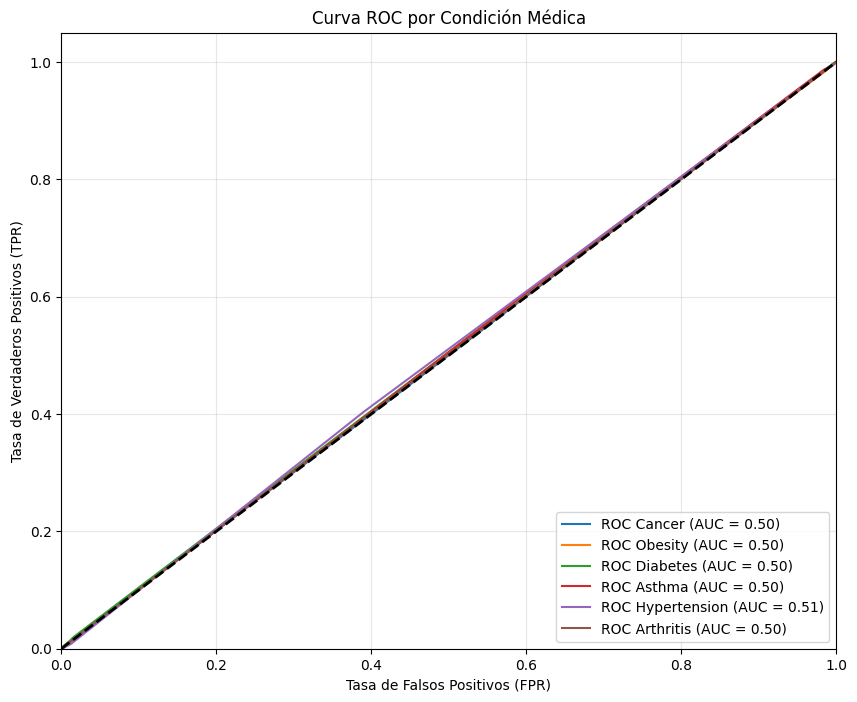

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# 1. Preparación de datos
df = pd.read_csv('evaluacionh2/healthcare_dataset.csv')
X = pd.get_dummies(df[['Age', 'Billing Amount', 'Gender', 'Blood Type']], drop_first=True)
y = df['Medical Condition']

# Binarizar la salida para multiclase
clases = y.unique()
y_bin = label_binarize(y, classes=clases)
n_classes = y_bin.shape[1]

x_train, x_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.2, random_state=42)

# 2. Entrenar el modelo
modelo = DecisionTreeClassifier(max_depth=4)
modelo.fit(x_train, y_train)

# 3. Calcular probabilidades para la curva ROC
y_score = modelo.predict_proba(x_test)

# 4. Generar la gráfica ROC (como en tu captura)
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_score[i][:, 1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC {clases[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Línea diagonal de referencia
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC por Condición Médica')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

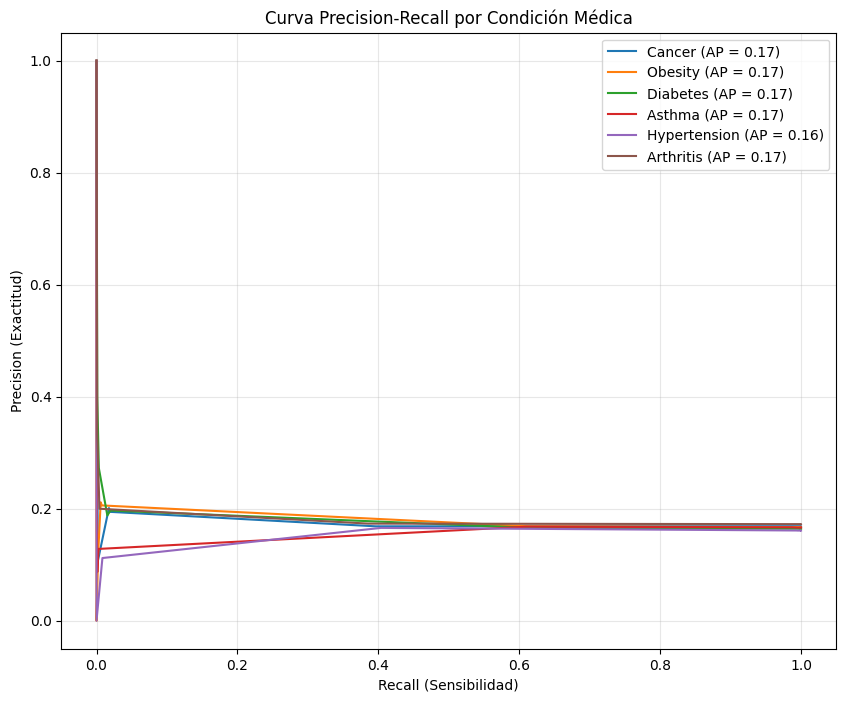

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score

# 1. Carga y preparación (consistente con los pasos anteriores)
df = pd.read_csv('evaluacionh2/healthcare_dataset.csv')
X = pd.get_dummies(df[['Age', 'Billing Amount', 'Gender', 'Blood Type']], drop_first=True)
y = df['Medical Condition']

# Binarizar para multiclase
clases = y.unique()
y_bin = label_binarize(y, classes=clases)
n_classes = y_bin.shape[1]

x_train, x_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.2, random_state=42)

# 2. Entrenar y obtener probabilidades
modelo = DecisionTreeClassifier(max_depth=4)
modelo.fit(x_train, y_train)
y_score = modelo.predict_proba(x_test)

# 3. Generar el Gráfico Precision-Recall
plt.figure(figsize=(10, 8))

for i in range(n_classes):
    # y_score para árboles devuelve una lista de arrays, tomamos la prob. de la clase positiva [:, 1]
    precision, recall, _ = precision_recall_curve(y_test[:, i], y_score[i][:, 1])
    average_precision = average_precision_score(y_test[:, i], y_score[i][:, 1])
    plt.plot(recall, precision, label=f'{clases[i]} (AP = {average_precision:.2f})')

plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precision (Exactitud)')
plt.title('Curva Precision-Recall por Condición Médica')
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.show()

In [60]:
from sklearn.tree import DecisionTreeRegressor, export_text

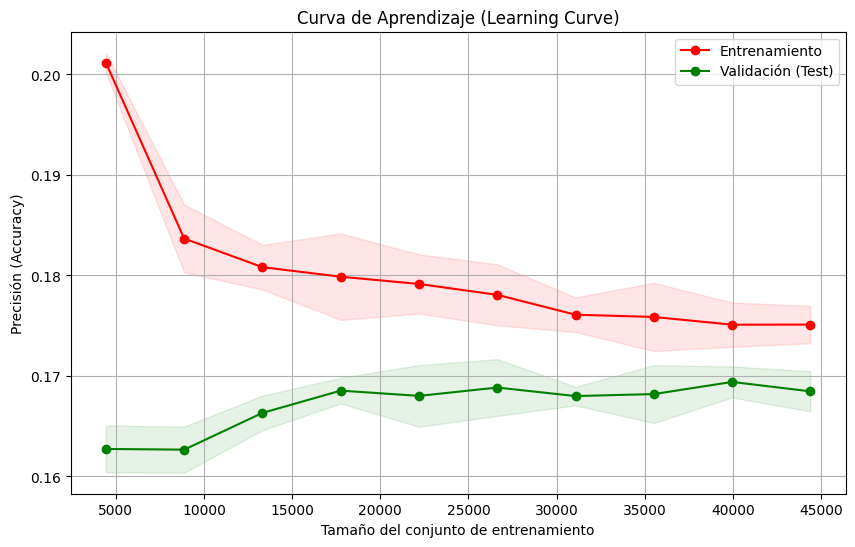

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import learning_curve, train_test_split

# 1. Preparación de datos
df = pd.read_csv('evaluacionh2/healthcare_dataset.csv')
X = pd.get_dummies(df[['Age', 'Billing Amount', 'Gender', 'Blood Type']], drop_first=True)
y = df['Medical Condition']

# 2. Configurar el modelo
modelo = DecisionTreeClassifier(max_depth=4)

# 3. Calcular la curva de aprendizaje
# cv=5 hace una validación cruzada de 5 pliegues
train_sizes, train_scores, test_scores = learning_curve(
    modelo, X, y, cv=5, scoring='accuracy', n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Calcular promedios y desviaciones estándar
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 4. Generar la gráfica (como en tu captura)
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Entrenamiento")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Validación (Test)")

# Dibujar las sombras de error
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

plt.title("Curva de Aprendizaje (Learning Curve)")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Precisión (Accuracy)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

In [63]:
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import train_test_split
import pandas as pd
import graphviz

In [64]:
x_train

,Age,Billing Amount,Gender_Male,Blood Type_A-,Blood Type_AB+,Blood Type_AB-,Blood Type_B+,Blood Type_B-,Blood Type_O+,Blood Type_O-
45174,22,42298.681572,False,False,False,False,False,False,True,False
10214,22,2437.435883,True,False,False,False,False,True,False,False
43199,81,5600.450992,False,False,False,False,False,False,False,False
31626,80,39533.300775,False,False,False,False,True,False,False,False
9273,26,37691.176763,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
44732,27,28005.689380,False,False,False,False,False,True,False,False
54343,32,2381.539677,True,False,False,True,False,False,False,False
38158,24,10502.693983,False,False,False,False,False,True,False,False
860,76,13014.330000,True,False,False,False,False,False,False,False


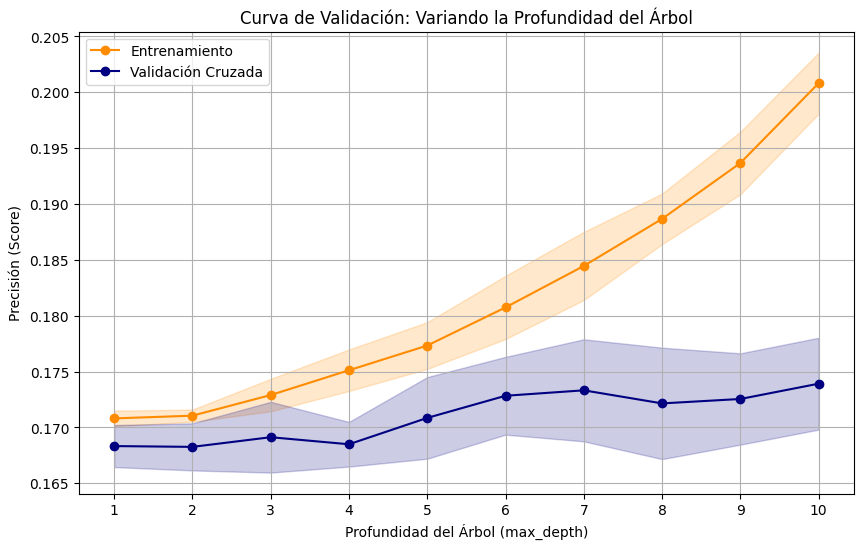

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import validation_curve

# 1. Carga de datos
df = pd.read_csv('evaluacionh2/healthcare_dataset.csv')
X = pd.get_dummies(df[['Age', 'Billing Amount', 'Gender', 'Blood Type']], drop_first=True)
y = df['Medical Condition']

# 2. Definir el rango del parámetro a evaluar (Profundidad del 1 al 10)
param_range = np.arange(1, 11)

# 3. Calcular la curva de validación
train_scores, test_scores = validation_curve(
    DecisionTreeClassifier(), X, y, 
    param_name="max_depth", 
    param_range=param_range,
    cv=5, scoring="accuracy", n_jobs=-1
)

# Promedios y desviación estándar
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 4. Graficar (como en tu captura)
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_mean, label="Entrenamiento", color="darkorange", marker='o')
plt.plot(param_range, test_mean, label="Validación Cruzada", color="navy", marker='o')

plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2, color="darkorange")
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2, color="navy")

plt.title("Curva de Validación: Variando la Profundidad del Árbol")
plt.xlabel("Profundidad del Árbol (max_depth)")
plt.ylabel("Precisión (Score)")
plt.xticks(param_range)
plt.legend(loc="best")
plt.grid(True)
plt.show()

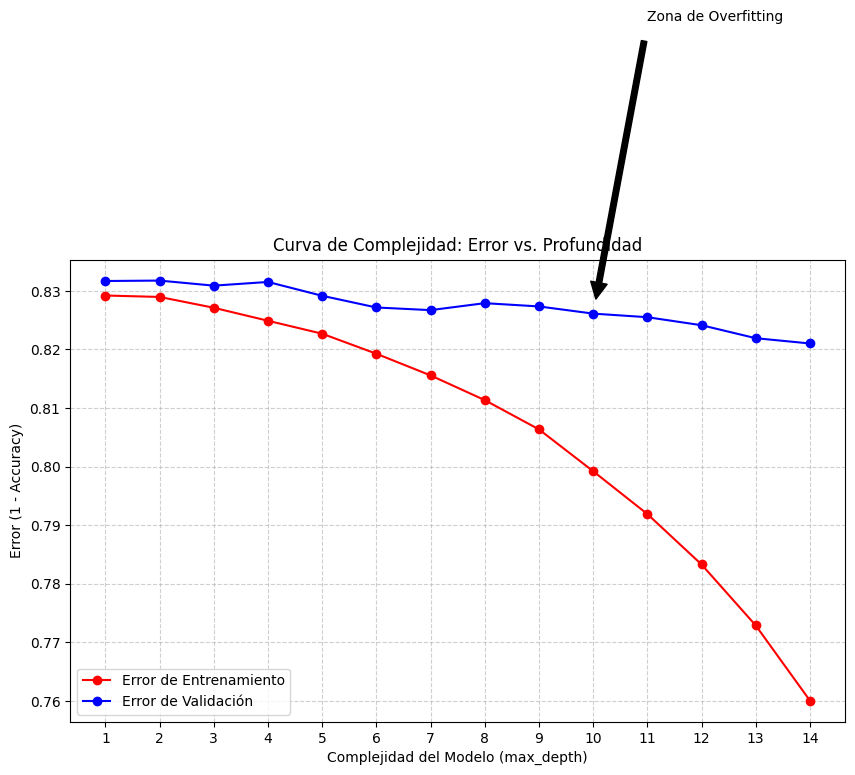

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import validation_curve

# 1. Carga y preparación
df = pd.read_csv('evaluacionh2/healthcare_dataset.csv')
X = pd.get_dummies(df[['Age', 'Billing Amount', 'Gender', 'Blood Type']], drop_first=True)
y = df['Medical Condition']

# 2. Definir rango de complejidad (Profundidad del árbol)
param_range = np.arange(1, 15)

# 3. Calcular error (1 - accuracy)
train_scores, test_scores = validation_curve(
    DecisionTreeClassifier(), X, y, 
    param_name="max_depth", param_range=param_range,
    cv=5, scoring="accuracy", n_jobs=-1
)

# Convertir precisión a error (Error = 1 - Score)
train_errors = 1 - np.mean(train_scores, axis=1)
test_errors = 1 - np.mean(test_scores, axis=1)

# 4. Graficar la Complejidad del Modelo
plt.figure(figsize=(10, 6))
plt.plot(param_range, train_errors, 'o-', label="Error de Entrenamiento", color="red")
plt.plot(param_range, test_errors, 'o-', label="Error de Validación", color="blue")

plt.title("Curva de Complejidad: Error vs. Profundidad")
plt.xlabel("Complejidad del Modelo (max_depth)")
plt.ylabel("Error (1 - Accuracy)")
plt.xticks(param_range)
plt.legend(loc="best")
plt.grid(True, linestyle='--', alpha=0.6)

# Marcar la zona de Overfitting
plt.annotate('Zona de Overfitting', xy=(10, test_errors[9]), xytext=(11, test_errors[9]+0.05),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.show()